# TF-IDF + Logistic Regression Baseline

Binary depression classification (PHQ-8 ≥ 10 → depressed) using TF-IDF features from participant transcripts and a logistic regression classifier.

- **Input**: `dataset/cleaned/{id}_P.txt` — cleaned participant transcripts
- **Labels**: `PHQ8_Binary` (train/dev) / `PHQ_Binary` (test) from AVEC-2017 CSVs
- **Splits**: official AVEC-2017 train / dev / test

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 1. Paths

In [29]:
REPO_ROOT      = Path("../")
DATASET_DIR    = REPO_ROOT / "dataset"
TRANSCRIPT_DIR = DATASET_DIR / "cleaned"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

## 2. Load labels

In [30]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]].rename(columns={"PHQ8_Binary": "label"})
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]].rename(columns={"PHQ8_Binary": "label"})
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(columns={"PHQ_Binary": "label"})

print(f"Train samples : {len(train_df)}  (depressed: {train_df.label.sum()})")
print(f"Dev   samples : {len(dev_df)}   (depressed: {dev_df.label.sum()})")
print(f"Test  samples : {len(test_df)}   (depressed: {test_df.label.sum()})")

Train samples : 107  (depressed: 30)
Dev   samples : 35   (depressed: 12)
Test  samples : 47   (depressed: 14)


## 3. Load transcripts

In [31]:
def load_transcripts(df: pd.DataFrame) -> tuple[list[str], list[int]]:
    """Return (texts, labels) for participants that have a transcript file."""
    texts, labels = [], []
    missing = []
    for _, row in df.iterrows():
        path = TRANSCRIPT_DIR / f"{row.Participant_ID}_P.txt"
        if path.exists():
            texts.append(path.read_text(encoding="utf-8").strip())
            labels.append(int(row.label))
        else:
            missing.append(row.Participant_ID)
    if missing:
        print(f"  Missing transcripts: {missing}")
    return texts, labels


train_texts, train_labels = load_transcripts(train_df)
dev_texts,   dev_labels   = load_transcripts(dev_df)
test_texts,  test_labels  = load_transcripts(test_df)

print(f"Loaded {len(train_texts)} train / {len(dev_texts)} dev / {len(test_texts)} test transcripts")

Loaded 107 train / 35 dev / 47 test transcripts


## 4. TF-IDF vectorisation

With only ~107 training samples, keeping `max_features` at 10 000 gives a ~93:1 feature-to-sample ratio — logistic regression will memorise the training set perfectly and generalise to nothing. A ~5:1 ratio (500 features) is a safe upper bound for this dataset size.

In [32]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=500,     # ~5x samples — avoids trivial memorisation
    sublinear_tf=True,    # replace tf with 1 + log(tf)
    min_df=2,
    strip_accents="unicode",
    analyzer="word",
)

X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)
X_test  = vectorizer.transform(test_texts)

print(f"Feature matrix — train: {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")

Feature matrix — train: (107, 500), dev: (35, 500), test: (47, 500)


## 5. Train logistic regression

Trained on train + dev combined (142 samples), evaluated on test. `C=0.1` adds stronger L2 regularisation to guard against overfitting on the small dataset.

In [33]:
clf = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
)

traindev_texts  = train_texts  + dev_texts
traindev_labels = train_labels + dev_labels
X_traindev = vectorizer.transform(traindev_texts)   # vocab already fitted on train

clf.fit(X_traindev, traindev_labels)
print(f"Training complete. ({len(traindev_labels)} samples)")

Training complete. (142 samples)


## 6. Evaluation

In [34]:
traindev_preds = clf.predict(X_traindev)
test_preds     = clf.predict(X_test)

traindev_acc = accuracy_score(traindev_labels, traindev_preds)
test_acc     = accuracy_score(test_labels,     test_preds)
traindev_f1  = f1_score(traindev_labels, traindev_preds)
test_f1      = f1_score(test_labels,     test_preds)

print(f"{'':20s} {'Train+Dev':>10} {'Test':>10}")
print(f"{'Accuracy':20s} {traindev_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'F1 (depression)':20s} {traindev_f1:>10.4f} {test_f1:>10.4f}")
print()
print("Test classification report:")
print(classification_report(test_labels, test_preds, target_names=["control", "depression"]))

                      Train+Dev       Test
Accuracy                 0.9437     0.5532
F1 (depression)          0.9091     0.3636

Test classification report:
              precision    recall  f1-score   support

     control       0.71      0.61      0.66        33
  depression       0.32      0.43      0.36        14

    accuracy                           0.55        47
   macro avg       0.52      0.52      0.51        47
weighted avg       0.60      0.55      0.57        47



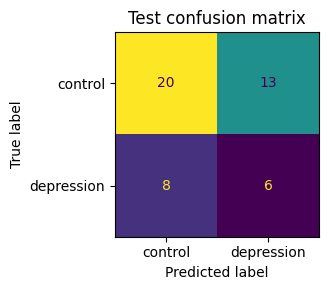

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(
    confusion_matrix(test_labels, test_preds),
    display_labels=["control", "depression"]
).plot(ax=ax, colorbar=False)
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()

## 7. Top discriminative tokens

In [36]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]

top_n = 15
top_dep_idx  = np.argsort(coefs)[-top_n:][::-1]
top_ctrl_idx = np.argsort(coefs)[:top_n]

token_df = pd.DataFrame({
    "depression token": feature_names[top_dep_idx],
    "depression coef":  coefs[top_dep_idx].round(4),
    "control token":    feature_names[top_ctrl_idx],
    "control coef":     coefs[top_ctrl_idx].round(4),
})

token_df

,depression token,depression coef,control token,control coef
0,and um,0.0604,brother,-0.0635
1,feel like,0.0577,wish,-0.0494
2,for me,0.0574,you know,-0.0450
3,lot,0.0545,shy,-0.0433
4,other people,0.0510,nice,-0.0430
5,think that,0.0503,the same,-0.0425
6,help,0.0491,same,-0.0408
7,and she,0.0480,relationship,-0.0392
8,the time,0.0447,pretty,-0.0384
9,things that,0.0440,our,-0.0384
